In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2


# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.utils import Utils
from stericheight.load_meop import MEOP
from region import Region
from functions import Functions
from OceanDataStore import OceanDataCatalog

pfns = PlottingFns()
fns = Functions()


In [3]:
import gsw
import cartopy
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
import xesmf as xe
import glob

lon = 145
refz=1000
fname_glorys1 = '../data/GLORYS/glorys_001.nc'
fname_glorys2 = '../data/GLORYS/glorys_002.nc'
fname_sose = '../data/SOSE/adelie3d/Jenny_AdelieSlices'
fname_clim = '../data/yamakazi_climatology.nc'
fname_zhou = '../data/CLIM_3D_forJenny.nc'


In [4]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [5]:
full_extent = [138, 150,-68,-64]
expanded_extent = [132, 156, -68, -62]

elevation = elevation_.sel(latitude = slice(expanded_extent[2], expanded_extent[3]), longitude = slice(expanded_extent[0],expanded_extent[1]))


In [6]:
# GET COLOURS
cdict = pickle.load(open('cdict.pkl','rb'))


In [7]:
climatology = xr.open_dataset(fname_clim).sel(latitude=slice(full_extent[2],full_extent[3])).sel(longitude=lon,method='nearest')
climatology['pres'] = gsw.conversions.p_from_z(-climatology.depth,climatology.latitude)
climatology['asal'] = gsw.conversions.SA_from_SP(climatology.psal,climatology.pres,lon,climatology.latitude)
climatology['ctemp'] = gsw.conversions.CT_from_t(climatology.asal,climatology.temp,climatology.pres)
climatology['sigma0'] = gsw.density.sigma0(climatology.asal,climatology.ctemp)

In [8]:
c_seasons = dict()
c_seasons['summer'] = climatology.sel(month=slice(0,3)).mean('month')
c_seasons['autumn'] = climatology.sel(month=slice(4,6)).mean('month')
c_seasons['winter'] = climatology.sel(month=slice(7,9)).mean('month')
c_seasons['spring'] = climatology.sel(month=slice(10,12)).mean('month')


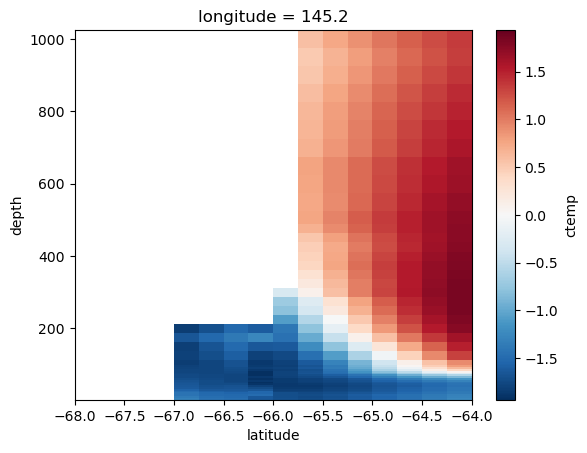

In [9]:
c_seasons['spring'].ctemp.plot()

In [10]:
def plot_transect(data,ax,title,vmin,vmax):
    im=data.plot.contourf(ax=ax,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance,add_colorbar=False,levels=40)
    #ax.set_title(title)
    # ax.set_ylim([1000,0])
    ax.set_xlim([-66.5,-64.5])
    ax.invert_yaxis()
    return im


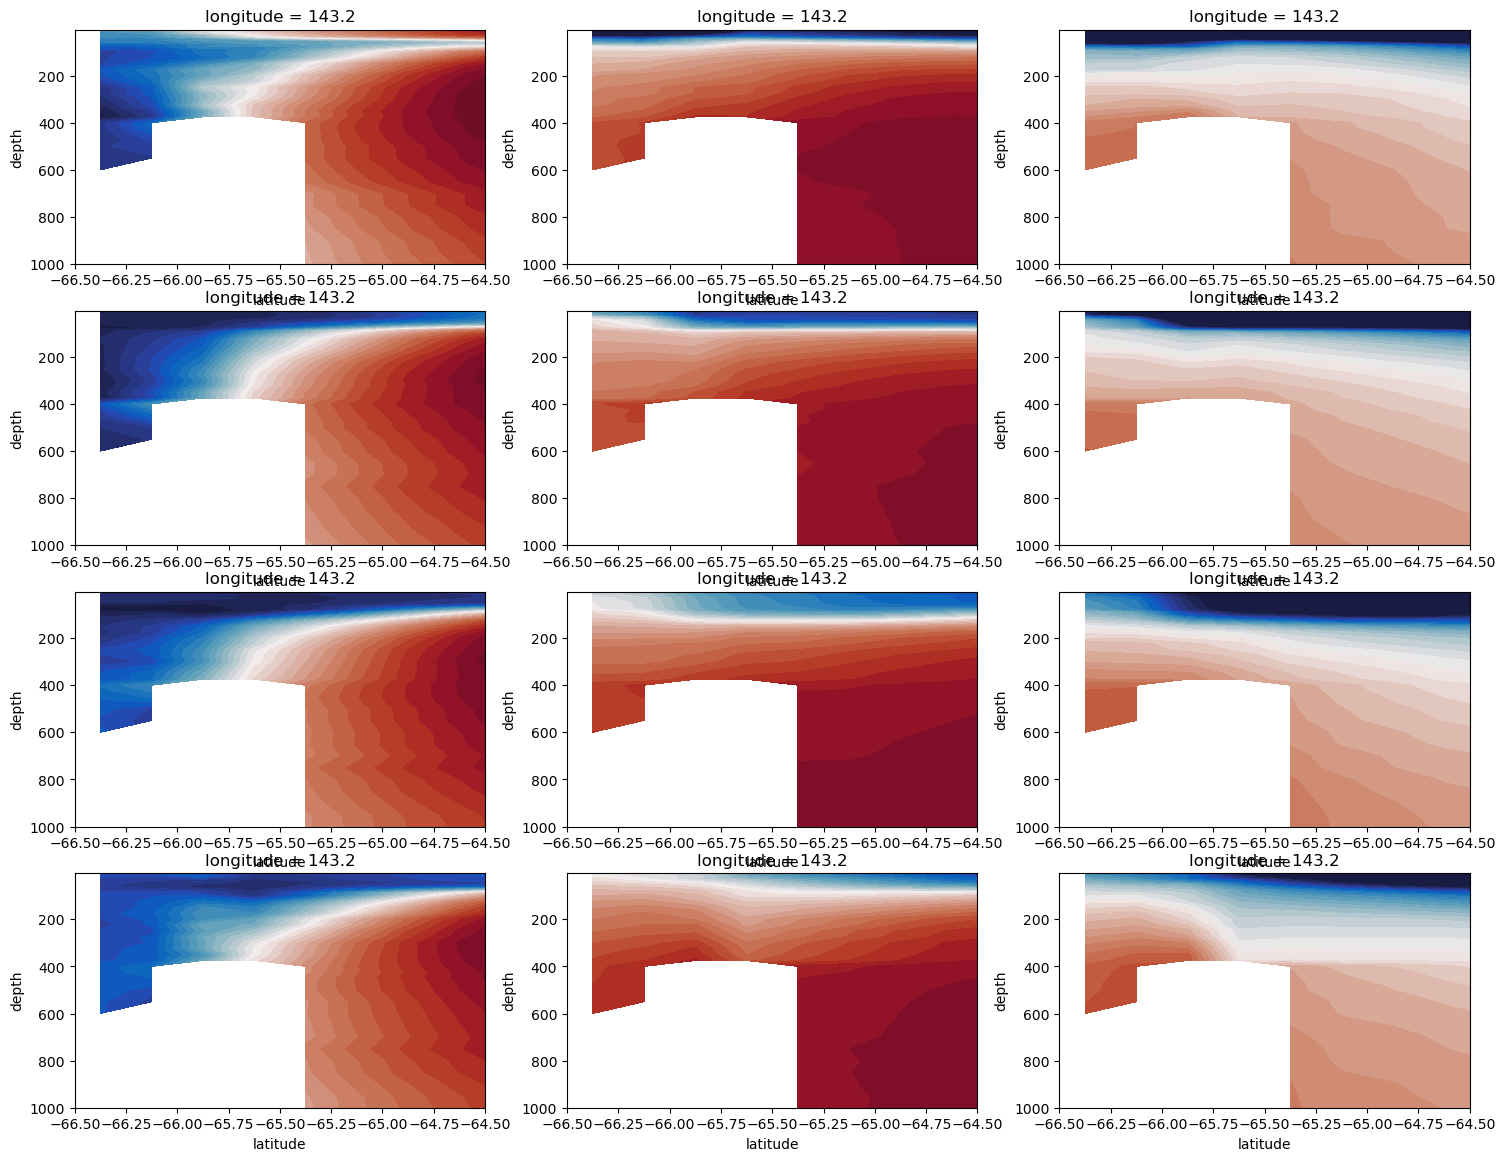

In [42]:
fig,axs = plt.subplots(4,3,figsize=(18,14))
for ssn,ax in zip(c_seasons,axs):
    plot_transect(c_seasons[ssn].ctemp,ax[0],'{} theta'.format(ssn),-2,2)
    plot_transect(c_seasons[ssn].asal,ax[1],'{} salinity'.format(ssn),34,35)
    plot_transect(c_seasons[ssn].sigma0,ax[2],'{} sigma0 '.format(ssn), 27.5, 28)

In [11]:
dscli = xr.open_dataset(fname_zhou)
dscli = dscli.squeeze().rename({'lat':'latitude','lon':'longitude','prs':'pressure'}) \
    .swap_dims({'NB_y':'latitude','NB_x':'longitude','NB_LEV':'pressure'})
dscli = fns.crop_to_extent(dscli,full_extent).sel(longitude=lon)
dscli['sigma0'] = gsw.density.sigma0(dscli.sa,dscli.ct)

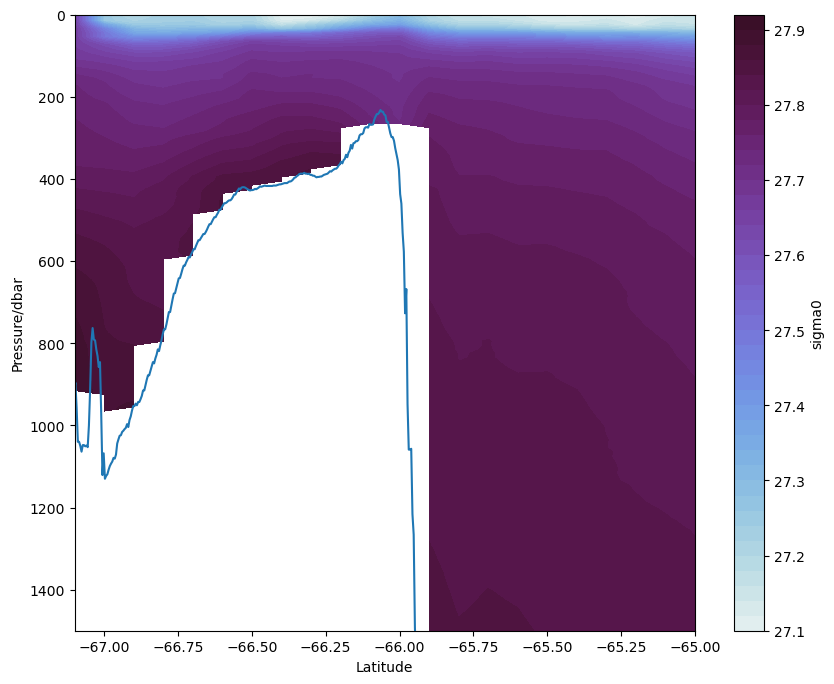

In [12]:
def plot_clim(ax,var,title,cmap):
    im=ax.contourf(dscli.latitude,dscli.pressure,dscli[var],cmap=cmap,levels=40)
    ax.plot(elevation.latitude,-elevation.sel(longitude=lon,method='nearest'))
    ax.set_ylim([0,1500])
    ax.set_xlim([-67.1,-65])
    ax.set_ylabel('Pressure/dbar')
    ax.set_xlabel('Latitude')
    #ax.set_yscale('log')
    ax.yaxis.set_inverted(True)

    cbar = plt.colorbar(im)
    cbar.set_label(title)

fig, ax=plt.subplots(1,1,figsize=(10,8))
plot_clim(ax,'sigma0','sigma0',cmocean.cm.dense)

In [13]:
sose = xr.open_dataset('spatial_average_sose.nc')
en4 = xr.open_dataset('spatial_average_en4.nc')
glorys = xr.open_dataset('spatial_average_glorys.nc')
nemo = xr.open_dataset('spatial_average_nemo.nc')

In [14]:
# use SOSE data to define time and loc bounds
extent = [sose.XC.min(), sose.XC.max(), sose.YC.min(), sose.YC.max()]

In [ ]:
sose=xr.open_mfdataset(glob.glob(fname_sose + '/*.nc'))

idx=sose.SALT.load() > 5
sose = sose.where(idx,np.nan)

# use SOSE data to define time and loc bounds
extent = [sose.XC.min(), sose.XC.max(), sose.YC.min(), sose.YC.max()]

sose['pres'] = gsw.conversions.p_from_z(sose.Z,sose.YC.mean())

sose = sose.swap_dims({'Z':'pres'}).drop_vars('Z')

# make monthly
sose=sose.resample({'time':'MS'}).mean()

#sose = sose.sel(pres=slice(0,1000))
sose['asal'] = gsw.SA_from_SP(sose.SALT,sose.pres,sose.XC,sose.YC)
sose['ctemp'] = gsw.CT_from_pt(sose.asal,sose.THETA)
sose['rho'] = gsw.density.rho(sose.asal,sose.ctemp,sose.pres)


In [ ]:
en4 = xr.open_dataset('en4_analysis.nc')
en4 = fns.crop_to_extent(en4,extent)

# sort time
en4 = en4.resample({'time':'MS'}).mean()
en4['month'] = en4.time.dt.month
en4['year'] = en4.time.dt.year

en4['pres'] = gsw.conversions.p_from_z(-en4.depth,en4.lat.mean())

en4 = en4.swap_dims({'depth':'pres'}).drop_vars('depth')

#en4 = en4.sel(pres=slice(0,1000))

en4['asal'] = gsw.SA_from_SP(en4.salinity,en4.pres,en4.lon,en4.lat)
en4['ctemp'] = gsw.CT_from_pt(en4.asal,en4.temperature-273.15)
en4['rho'] = gsw.density.rho(en4.asal,en4.ctemp,en4.pres)


In [17]:
# define time bounds covering both datasets
t1 = sose.time[0]
t2 = glorys.time[-1]


In [ ]:
ds1 = xr.open_dataset(fname_glorys1)
ds2 = xr.open_dataset(fname_glorys2)
glorys = xr.merge([ds1,ds2])

glorys = fns.crop_to_extent(glorys,extent).coarsen({'latitude':6,'longitude':6}).mean()
# make monthly
glorys = glorys.resample({'time':'MS'}).mean()
glorys['pres'] = gsw.conversions.p_from_z(-glorys.depth,glorys.latitude.mean())

glorys = glorys.swap_dims({'depth':'pres'}).drop_vars('depth')#.sel(pres=slice(0,1000))

glorys['asal'] = gsw.SA_from_SP(glorys.so,glorys.pres,glorys.longitude,glorys.latitude)
glorys['ctemp'] = gsw.CT_from_pt(glorys.asal,glorys.thetao)
glorys['rho'] = gsw.density.rho(glorys.asal,glorys.ctemp,glorys.pres)



/tmp/ipykernel_628164/3220510806.py:3: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  glorys = xr.merge([ds1,ds2])


In [ ]:
# load nemo data
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
nemo = catalog.open_dataset(id='noc-npd-era5/npd-eorca12-era5v1/gn/T1m_4d',variable_names=['thetao_con','so_abs'])

# prepare nemo
# crop to region
lats = nemo.nav_lat.load()
lons = nemo.nav_lon.load()
mask = (lats >= extent[2]) & (lats <= extent[3]) & (lons >= extent[0]) & (lons <= extent[1])
# crop to area and coarsen
nemo = nemo.where(mask,drop=True).coarsen({'y':6,'x':6},boundary='trim').mean()

# make monthly
nemo = nemo.rename({'time_counter':'time'}).resample({'time':'MS'}).mean()

nemo['pres'] = gsw.conversions.p_from_z(-nemo.deptht,nemo.nav_lat.mean())

nemo = nemo.swap_dims({'deptht':'pres'}).drop_vars('deptht')#.sel(pres=slice(0,1000))

nemo['rho'] = gsw.density.rho(nemo.so_abs,nemo.thetao_con,nemo.pres)



  2026-06-01T08:48:35.407931Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: HTTP read timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: HttpTimeoutError { kind: "HTTP read", duration: 1s }, connection: Unknown } }) }))
    at /root/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



In [20]:
t1 = sose.time[0]
t2 = glorys.time[-1]

In [21]:
# assign colours for easy plotting
colors = {'SHA': 'rebeccapurple',
          'GPHA': 'lightsteelblue',
          'GLORYS': 'lightseagreen',
          'NEMO' : 'palevioletred',
          'SOSE' : 'orange',
          'EN4': 'dodgerblue',
          'MASS': 'grey'}


In [22]:
glorys

<xarray.Dataset> Size: 90MB
Dimensions:    (time: 252, latitude: 9, longitude: 28, pres: 35)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2002-01-01 2002-02-01 ... 2022-12-01
  * latitude   (latitude) float32 36B -67.29 -66.79 -66.29 ... -63.79 -63.29
  * longitude  (longitude) float32 112B 138.2 138.7 139.2 ... 150.7 151.2 151.7
  * pres       (pres) float64 280B 0.4989 1.557 2.672 ... 651.0 772.3 913.3
Data variables:
    siconc     (time, latitude, longitude) float32 254kB nan nan nan ... nan nan
    mlotst     (time, latitude, longitude) float32 254kB nan nan ... 28.31 28.75
    sithick    (time, latitude, longitude) float32 254kB nan nan nan ... nan nan
    zos        (time, latitude, longitude) float32 254kB nan nan ... -1.573
    thetao     (time, pres, latitude, longitude) float32 9MB nan nan ... 1.481
    so         (time, pres, latitude, longitude) float32 9MB nan nan ... 34.73
    bottomT    (time, latitude, longitude) float32 254kB nan nan ... -0.08772
    uo         (time, pres, latitude, longitude) float32 9MB nan ... -5.086e-05
    vo         (time, pres, latitude, longitude) float32 9MB nan ... 0.005375
    asal       (time, pres, latitude, longitude) float64 18MB nan nan ... 34.91
    ctemp      (time, pres, latitude, longitude) float64 18MB nan nan ... 1.481
    rho        (time, pres, latitude, longitude) float64 18MB nan ... 1.032e+03
Attributes:
    Conventions:       CF-1.11
    title:             Monthly mean fields for product GLOBAL_REANALYSIS_PHY_...
    institution:       Mercator Ocean
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            MERCATOR GLORYS12V1
    credit:            E.U. Copernicus Marine Service Information (CMEMS)
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        http://marine.copernicus.eu
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_MULTIYEAR_PHY_001_030
    subset:datasetId:  cmems_mod_glo_phy_my_0.083deg_P1M-m_202311
    subset:date:       2025-12-04T07:49:47.532Z

In [23]:
sose['sigma0'] = gsw.density.sigma0(sose.asal,sose.ctemp)
nemo['sigma0'] = gsw.density.sigma0(nemo.so_abs,nemo.thetao_con)
glorys['sigma0'] = gsw.density.sigma0(glorys.asal,glorys.ctemp)
en4['sigma0'] = gsw.density.sigma0(en4.asal,en4.ctemp)


soselon = sose.sel(XC=lon,method='nearest').mean('time')
nemolon = nemo.sel(x=lon,method='nearest').mean('time')
gloryslon = glorys.sel(longitude=lon,method='nearest').mean('time')
en4lon = en4.sel(lon=lon,method='nearest').mean('time')


In [24]:
soselon

<xarray.Dataset> Size: 5MB
Dimensions:  (XG: 97, YC: 89, YG: 88, Zu: 52, Zl: 52, Zp1: 53, pres: 35)
Coordinates: (12/21)
  * XG       (XG) float64 776B 137.0 137.2 137.3 137.5 ... 152.7 152.8 153.0
    dxC      (YC, XG) float64 69kB dask.array<chunksize=(89, 97), meta=np.ndarray>
    dyG      (YC, XG) float64 69kB dask.array<chunksize=(89, 97), meta=np.ndarray>
    rAw      (YC, XG) float64 69kB dask.array<chunksize=(89, 97), meta=np.ndarray>
    hFacW    (pres, YC, XG) float64 2MB dask.array<chunksize=(35, 89, 97), meta=np.ndarray>
  * YC       (YC) float64 712B -68.97 -68.91 -68.85 ... -63.19 -63.11 -63.03
    ...       ...
  * Zl       (Zl) float64 416B 0.0 -4.2 -9.2 ... -4.8e+03 -5.2e+03 -5.6e+03
  * Zp1      (Zp1) float64 424B 0.0 -4.2 -9.2 -15.1 ... -5.2e+03 -5.6e+03 -6e+03
    drC      (Zp1) float64 424B dask.array<chunksize=(53,), meta=np.ndarray>
  * pres     (pres) float64 280B 2.121 6.767 12.27 18.74 ... 708.2 809.6 911.0
    drF      (pres) float64 280B 4.2 5.0 5.9 6.9 8.5 ... 72.0 100.0 100.0 100.0
    XC       float64 8B 144.9
Data variables:
    ETAN     (YC, pres) float32 12kB dask.array<chunksize=(89, 35), meta=np.ndarray>
    SIarea   (YC, pres) float32 12kB dask.array<chunksize=(89, 35), meta=np.ndarray>
    SIheff   (YC, pres) float32 12kB dask.array<chunksize=(89, 35), meta=np.ndarray>
    THETA    (pres, YC) float32 12kB dask.array<chunksize=(35, 89), meta=np.ndarray>
    SALT     (pres, YC) float32 12kB nan nan nan nan ... 34.73 34.73 34.73 34.73
    UVEL     (pres, YC, XG) float32 1MB dask.array<chunksize=(35, 89, 97), meta=np.ndarray>
    VVEL     (pres, YG, YC) float32 1MB dask.array<chunksize=(35, 88, 89), meta=np.ndarray>
    asal     (pres, YC) float64 25kB nan nan nan nan nan ... 34.9 34.9 34.9 34.9
    ctemp    (pres, YC) float64 25kB dask.array<chunksize=(35, 89), meta=np.ndarray>
    rho      (pres, YC) float64 25kB dask.array<chunksize=(35, 89), meta=np.ndarray>
    sigma0   (pres, YC) float64 25kB dask.array<chunksize=(35, 89), meta=np.ndarray>

In [25]:
def plot_clim(ax,da,lat,pres,title,cmap):
    im=ax.contourf(lat,pres,da,cmap=cmap,levels=40)
    ax.plot(elevation.latitude,-elevation.sel(longitude=lon,method='nearest'))
    ax.set_ylim([0,1500])
    ax.set_xlim([-67.1,-65])
    ax.set_ylabel('Pressure/dbar')
    ax.set_xlabel('Latitude')
    #ax.set_yscale('log')
    ax.yaxis.set_inverted(True)

    cbar = plt.colorbar(im)
    cbar.set_label(title)


In [26]:
soselon.load()
nemolon.load()
gloryslon.load()
en4lon.load()

KeyboardInterrupt: 

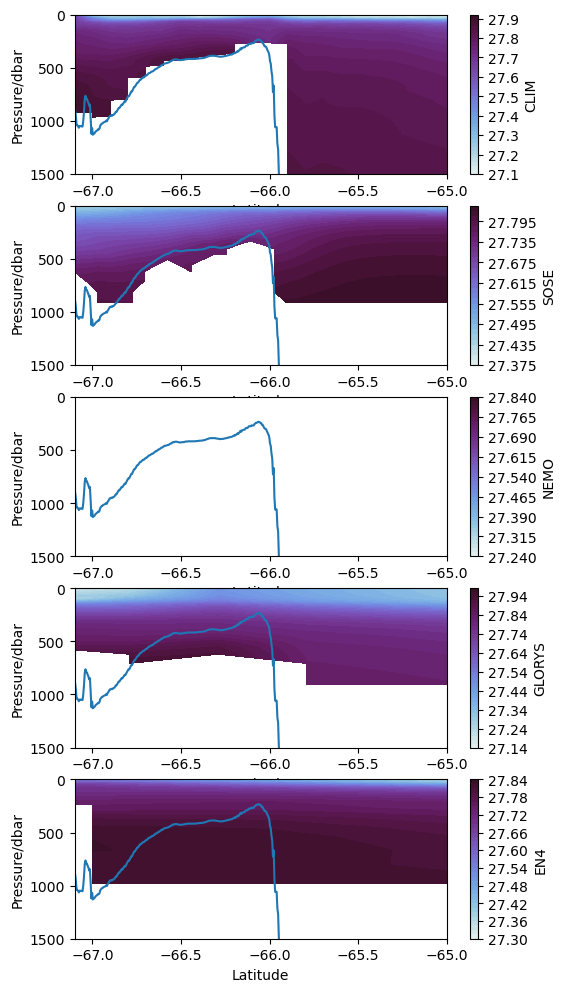

In [ ]:
fig,ax = plt.subplots(5,1,figsize=(6,12))
plot_clim(ax[0],dscli.sigma0,dscli.latitude,dscli.pressure,'CLIM',cmocean.cm.dense)
plot_clim(ax[1],soselon.sigma0,soselon.YC,soselon.pres,'SOSE',cmocean.cm.dense)
plot_clim(ax[2],nemolon.sigma0,nemolon.y,nemolon.pres,'NEMO',cmocean.cm.dense)
plot_clim(ax[3],gloryslon.sigma0,gloryslon.latitude,soselon.pres,'GLORYS',cmocean.cm.dense)
plot_clim(ax[4],en4lon.sigma0,en4lon.lat,en4lon.pres,'EN4',cmocean.cm.dense)
